Database Path: C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
Connected to the database at C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
             date_time  close_price
0  2024-11-01 09:30:00   221.429993
1  2024-11-01 09:31:00   222.070007
2  2024-11-01 09:32:00   221.259995
3  2024-11-01 09:33:00   221.559998
4  2024-11-01 09:34:00   222.240005


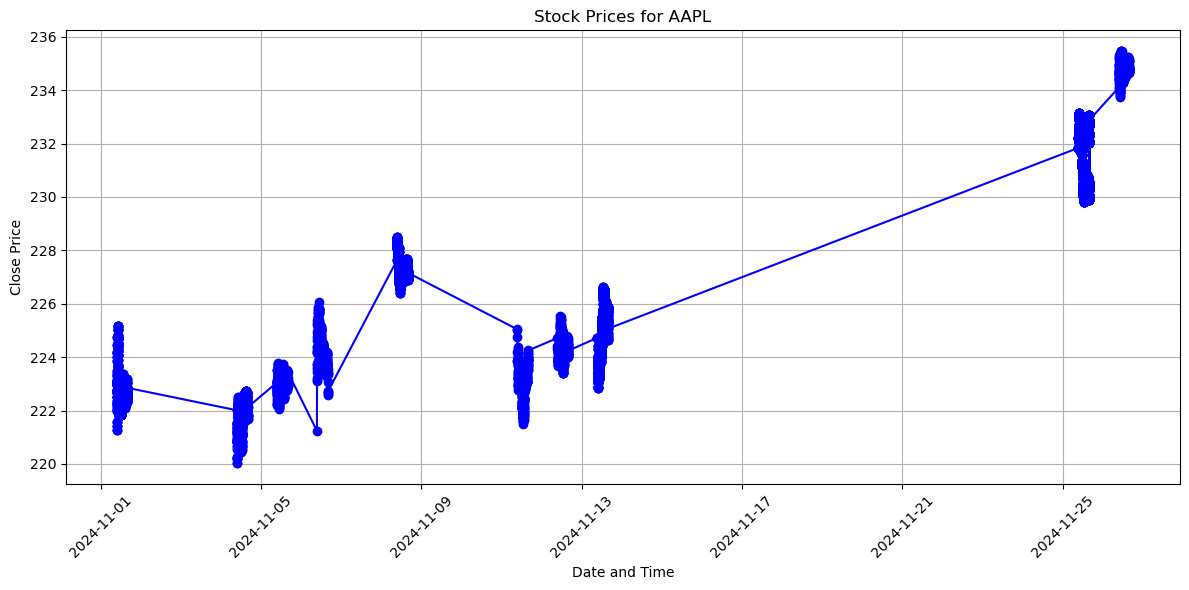

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import os

# Construct the path to the database
BASE_DIR = r'C:\Users\91940\Documents\Trade_buddy\scripts'
DB_PATH = os.path.join(BASE_DIR, 'C:/Users/91940/Documents/Trade_buddy/data/processed/stock_data.db')

# Normalize the path to handle '..'
DB_PATH = os.path.normpath(DB_PATH)

# Print to confirm the correct path
print("Database Path:", DB_PATH)
SQL_PATH = os.path.join(BASE_DIR, '../models/create_tables.sql')

def create_connection():
    """ Create a database connection to the SQLite database """
    conn = None
    try:
        conn = sqlite3.connect(DB_PATH)
        print(f"Connected to the database at {DB_PATH}")
    except sqlite3.Error as e:
        print(f"Error connecting to the database: {e}")
    return conn

def visualize_stock_data(ticker):
    """ Visualize stock prices from the database """
    conn = create_connection()
    if conn:
        query = f"SELECT date_time, close_price FROM stock_data WHERE ticker='{ticker}'"
        df = pd.read_sql_query(query, conn)
        print(df.head())
        conn.close()

        # Convert date_time to datetime for plotting
        df['date_time'] = pd.to_datetime(df['date_time'])

        # Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(df['date_time'], df['close_price'], marker='o', linestyle='-', color='b')
        plt.title(f'Stock Prices for {ticker}')
        plt.xlabel('Date and Time')
        plt.ylabel('Close Price')
        plt.xticks(rotation=45)
        plt.grid()
        plt.tight_layout()
        plt.show()
    
if __name__ == '__main__':
    ticker = 'AAPL'  # Example: Fetch and store Apple's stock data
    visualize_stock_data(ticker)

In [14]:
conn = create_connection()
if conn:
    query = f"SELECT * FROM stock_data WHERE ticker='{ticker}'"
    df = pd.read_sql_query(query, conn)
    print(df.head(),len(df))
    conn.close()
    

Connected to the database at C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
   id ticker            date_time  open_price  high_price   low_price  \
0   1   AAPL  2024-11-01 09:30:00  220.970001  221.830002  220.279999   
1   2   AAPL  2024-11-01 09:31:00  221.384995  222.330002  221.028107   
2   3   AAPL  2024-11-01 09:32:00  222.160004  222.300003  221.190002   
3   4   AAPL  2024-11-01 09:33:00  221.259995  222.039993  221.169998   
4   5   AAPL  2024-11-01 09:34:00  221.550003  222.240005  221.529999   

   close_price   volume  
0   221.429993  4690276  
1   222.070007   659814  
2   221.259995   543082  
3   221.559998   550074  
4   222.240005   466803   12118


In [15]:
conn = create_connection()
if conn:
    query = f"SELECT * FROM stock_data_transformed WHERE ticker='{ticker}'"
    df = pd.read_sql_query(query, conn)
    print(df.tail(),len(df))
    conn.close()
    

Connected to the database at C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
      ticker            date_time  close_price  volume
12113   AAPL  2024-11-27 10:57:00   234.889999   74950
12114   AAPL  2024-11-27 10:58:00   234.690002  187068
12115   AAPL  2024-11-27 10:59:00   234.619995   63491
12116   AAPL  2024-11-27 11:00:00   234.699997   61383
12117   AAPL  2024-11-27 11:01:00   234.649994       0 12118
